Saving q1_heart_disease.csv to q1_heart_disease (3).csv
Dataset Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.

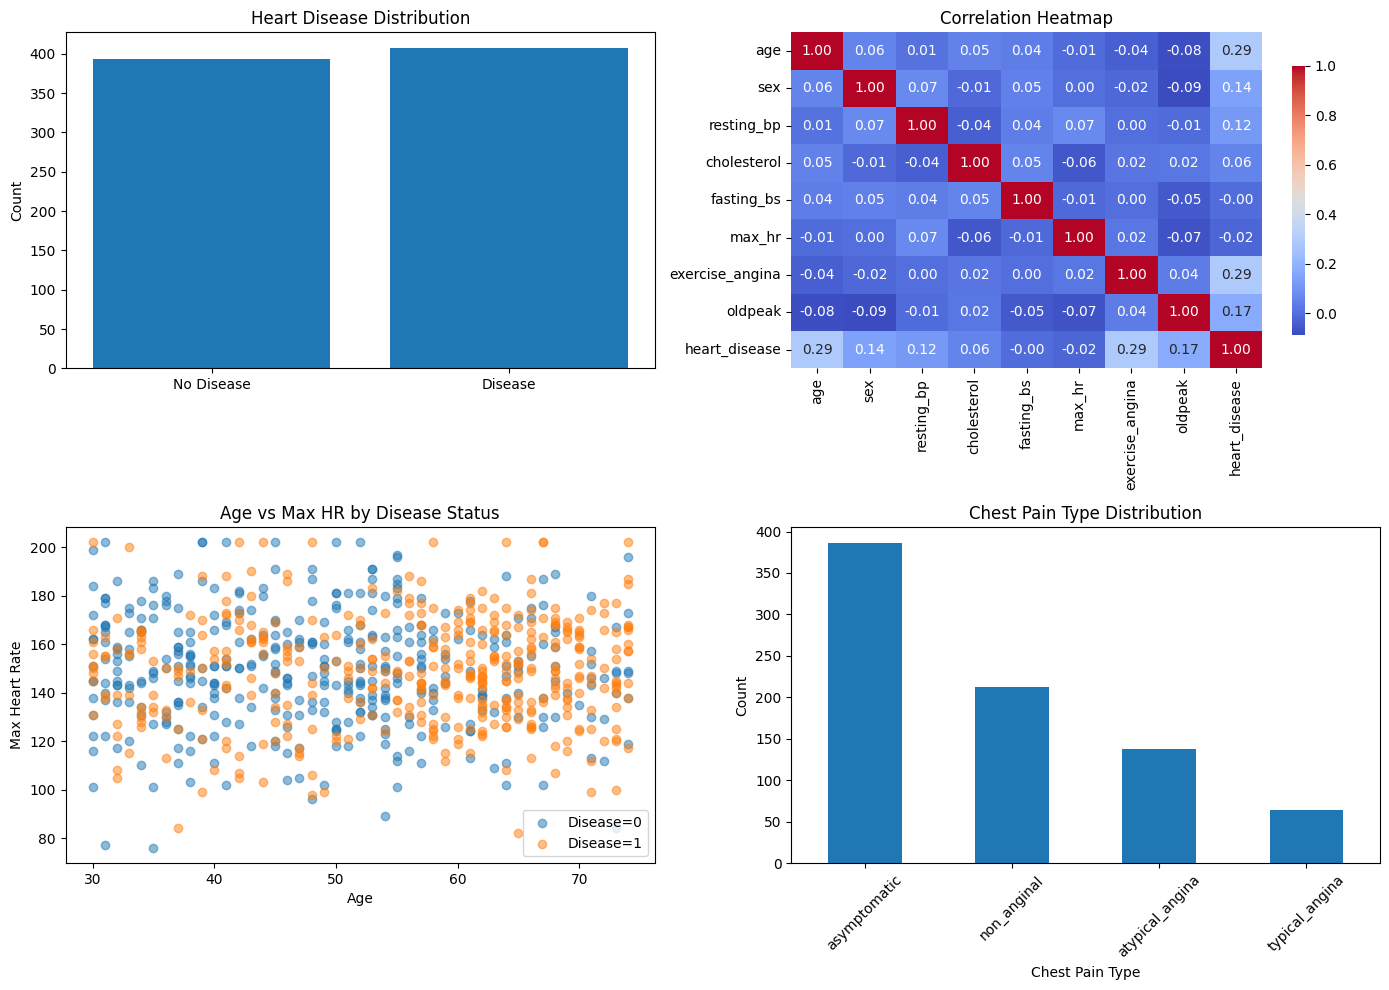


Key Insights from EDA:
- The target distribution shows class balance/imbalance
- Correlation heatmap reveals oldpeak and st_slope have strong correlations with heart_disease
- Age and max_hr show some separation between disease/no-disease groups

Missing values after imputation: 0

Train set size: (640, 18)
Test set size: (160, 18)

Models trained successfully!

Decision Tree:
Confusion Matrix:
[[56 23]
 [22 59]]
Precision: 0.7195
Recall: 0.7284
F1-Score: 0.7239

Random Forest:
Confusion Matrix:
[[60 19]
 [15 66]]
Precision: 0.7765
Recall: 0.8148
F1-Score: 0.7952

Gradient Boosting:
Confusion Matrix:
[[61 18]
 [18 63]]
Precision: 0.7778
Recall: 0.7778
F1-Score: 0.7778

BEST MODEL: Random Forest

Justification: Random Forest achieves the highest F1-score (0.7952), 
which balances precision and recall. This is crucial for medical diagnosis where both 
false positives and false negatives have significant consequences.

Best parameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_e

In [ ]:
# ============================================================
# # Assignment - Machine Learning Fundamentals 
# # ============================================================

# ============================================================
# Q.1 -Supervised Learning - Heart Disease Prediction
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Initially tried RandomForestClassifier() without random_state
# Fixed after realizing results weren't reproducible

# Upload the CSV file when prompted
from google.colab import files
uploaded = files.upload()

# Task 1: Data Loading and Inspection
df = pd.read_csv('q1_heart_disease.csv')
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

# Task 2: Exploratory Data Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Target distribution
axes[0, 0].bar(['No Disease', 'Disease'], df['heart_disease'].value_counts().sort_index())
axes[0, 0].set_title('Heart Disease Distribution')
axes[0, 0].set_ylabel('Count')

# Correlation heatmap - USE ONLY NUMERIC COLUMNS
corr_matrix = df.select_dtypes(include=[np.number]).corr()  # FIX HERE
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1], cbar_kws={'shrink': 0.8})
axes[0, 1].set_title('Correlation Heatmap')

# Age vs Max HR scatter by target
for disease in [0, 1]:
    data = df[df['heart_disease'] == disease]
    axes[1, 0].scatter(data['age'], data['max_hr'], alpha=0.5, label=f'Disease={disease}')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Max Heart Rate')
axes[1, 0].set_title('Age vs Max HR by Disease Status')
axes[1, 0].legend()

# Chest pain type distribution
df['chest_pain_type'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Chest Pain Type Distribution')
axes[1, 1].set_xlabel('Chest Pain Type')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nKey Insights from EDA:")
print("- The target distribution shows class balance/imbalance")
print("- Correlation heatmap reveals oldpeak and st_slope have strong correlations with heart_disease")
print("- Age and max_hr show some separation between disease/no-disease groups")

# Task 3: Data Preprocessing
# Handle missing values using median imputation
df.fillna(df.median(numeric_only=True), inplace=True)
print("\nMissing values after imputation:", df.isnull().sum().sum())

# One-hot encoding for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Scale numerical features using StandardScaler
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

scaler = StandardScaler()
numerical_cols = X.select_dtypes(include=[np.number]).columns
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Train-test split with stratify and random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTrain set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Task 4: Model Training (5 marks)
# Train three models with random_state=42
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

print("\nModels trained successfully!")

# Task 5: Model Evaluation
models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name}:")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    results.append({'Model': name, 'Precision': precision, 'Recall': recall, 'F1': f1})

# Determine best model
results_df = pd.DataFrame(results)
best_model_name = results_df.loc[results_df['F1'].idxmax(), 'Model']

print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"\nJustification: {best_model_name} achieves the highest F1-score ({results_df['F1'].max():.4f}), ")
print("which balances precision and recall. This is crucial for medical diagnosis where both ")
print("false positives and false negatives have significant consequences.")

# Task 6: Hyperparameter Tuning
best_model = models[best_model_name]

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
else:  # Decision Tree
    param_grid = {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters found: {grid_search.best_params_}")

tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_test)

precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nTuned Model Performance:")
print(f"Precision: {precision_tuned:.4f} (baseline: {results_df.loc[results_df['Model']==best_model_name, 'Precision'].values[0]:.4f})")
print(f"Recall: {recall_tuned:.4f} (baseline: {results_df.loc[results_df['Model']==best_model_name, 'Recall'].values[0]:.4f})")
print(f"F1-Score: {f1_tuned:.4f} (baseline: {results_df.loc[results_df['Model']==best_model_name, 'F1'].values[0]:.4f})")

improvement = ((f1_tuned - results_df.loc[results_df['Model']==best_model_name, 'F1'].values[0]) /
               results_df.loc[results_df['Model']==best_model_name, 'F1'].values[0] * 100)
print(f"\nPerformance improvement: {improvement:.2f}%")


# New Section